**What is linear Regression (LR)?**

It's a method used to predict the value of a variable based on the value of another variable. One variable is considered to be an explanatory/independent variable, and the other is considered to be a dependent/target variable.

Mathematically, finding the best fit line that satisfy the following Equation

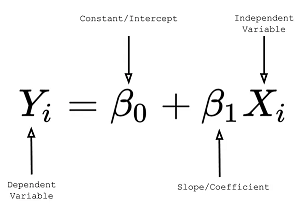



---

**Example of Simple Linear Regression (SLR) model**


---




**Step 1:** import the required libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

**Step 2**: upload the dataset "ex: student_score"

https://github.com/mrunalmetkar/Linear_Regression/blob/main/student_scores%20-%20student_scores.csv

In [ ]:
df=pd.read_csv("student_scores.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
# how many samples (rows) and (columns)
df.shape

(25, 2)

**Step #3**: Decide independent (input) and dependent variable (output)

In [ ]:
X=df.drop('Scores',axis=1)     # axis=1 --> drop the colums while axis=0 --> drop the rows
y= df['Scores']

# you can check X or y
# X
# y

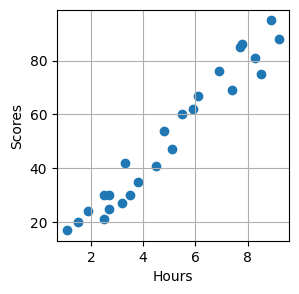

In [ ]:
# Figure the relationship between X and y (Hours and Scores)
plt.figure(figsize=(3,3))
plt.scatter(X,y)
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.grid(True)
plt.show()

# this is a relation between the input and actual respone and we need to get
# the predicted response

**Step #4**: Import the required libraries for linear regression model

In [ ]:
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

**Step #5**: split the dataset to training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# test_size=0.2 means traing set is 80% and testing set is 20%
# random_state controls the shuffling applied to the data before applying the split.

# X_train    # the training samples
# X_test     # the testing samples

**Step #6**: Initialize the LR model and set the hyperparameters

Linear regression takes no hyperparameters, so just initialize the model.

In [ ]:
from sklearn.linear_model import LinearRegression
# Create a linear regression model and fit it on the training data
model = LinearRegression()

# fit the model
model.fit(X_train,y_train)

# get the values of intercept and slope
beta_0 = model.intercept_
beta_1 = model.coef_
print("Estimated model intercept, B0:" , "{:.2f}".format(beta_0))
print("Estimated model slope, B1:" , beta_1)

Estimated model intercept, B0: 2.83
Estimated model slope, B1: [9.68207815]


**Step #7**: calculate the actual and predicted "estimated" values in both traing and testing

In [ ]:
y_predict_train=model.predict(X_train)
y_predict_test=model.predict(X_test)

In [ ]:
# the predicted values in the training case
y_predict_train

array([28.96850337, 34.77775026, 52.20549094, 39.61878934, 17.35000959,
       33.80954245, 46.39624405, 88.99738793, 85.12455667, 36.71416589,
       28.96850337, 21.22284085, 49.3008675 , 61.8875691 , 78.34710196,
       56.0783222 , 77.37889414, 13.47717832, 74.4742707 , 91.90201137])

In [ ]:
# the predicted values in the testing case
y_predict_test

array([83.18814104, 27.03208774, 27.03208774, 69.63323162, 59.95115347])

**Step #8**: draw the actual and predicted "estimated" values in both traing and testing

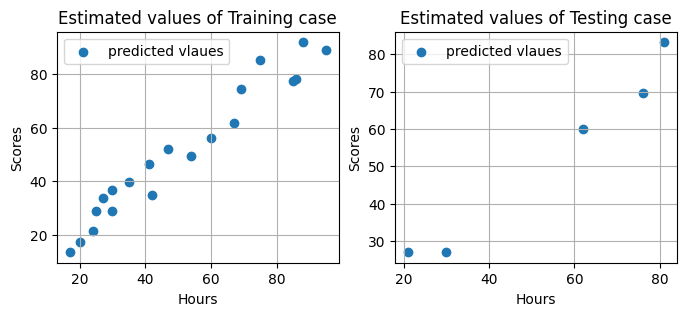

In [ ]:
plt.figure(figsize=(8,3))

# subplot 1
plt.subplot(1,2,1)   # as a matrix 1 row, 1 column, the first plot
plt.scatter(y_train,y_predict_train , label="predicted vlaues")
plt.title('Estimated values of Training case')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.legend()
plt.grid('True')

# subplot 2
plt.subplot(1,2,2)   # as a matrix 1 row, 1 column, the second plot
plt.scatter(y_test,y_predict_test, label="predicted vlaues")
plt.title('Estimated values of Testing case')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.legend()
plt.grid('True')

plt.show()

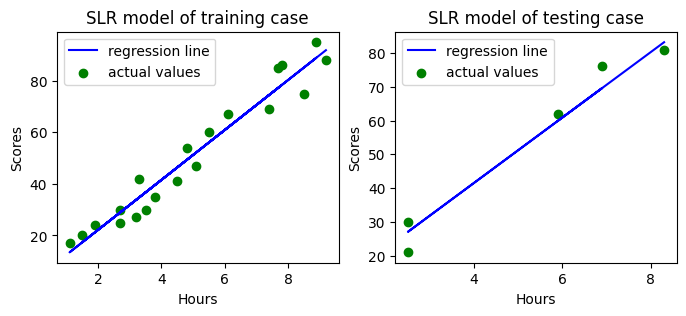

In [ ]:
plt.figure(figsize=(8,3))

# subplot 1
plt.subplot(1,2,1)   # as a matrix 1 row, 1 column, the first plot
plt.plot(X_train, y_predict_train, color='blue', label='regression line')
plt.scatter(X_train, y_train, c='green', label='actual values')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.title('SLR model of training case')
plt.legend()

# subplot 2
plt.subplot(1,2,2)   # as a matrix 1 row, 1 column, the second plot
plt.plot(X_test, y_predict_test, color='blue', label='regression line')
plt.scatter(X_test, y_test, c='green', label='actual values')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.title('SLR model of testing case')
plt.legend()

In [ ]:
# convert the actual and predicted values in a tabular form for training
error_train = pd.DataFrame(
    {
     'Actual-Values': y_train,
     'Predicted-Values': y_predict_train
     }
    )
error_train.head()


,Actual-Values,Predicted-Values
9,25,28.968503
13,42,34.777750
1,47,52.205491
22,35,39.618789
5,20,17.350010


In [ ]:
# convert the actual and predicted values in a tabular form for testing
error_test = pd.DataFrame(
    {'Actual-Values': y_test,
     'Predicted-Values': y_predict_test
     }
    )
error_test.head()

,Actual-Values,Predicted-Values
8,81,83.188141
16,30,27.032088
0,21,27.032088
23,76,69.633232
11,62,59.951153


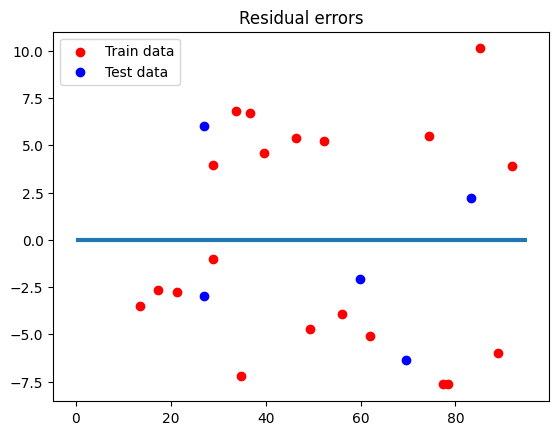

In [ ]:
# Plotting residual errors "Residual analysis"
plt.scatter(y_predict_train, y_predict_train - y_train, color = 'red', label = 'Train data')
plt.scatter(y_predict_test, y_predict_test - y_test, color = 'blue', label = 'Test data')
plt.hlines(xmin=0, xmax=y.max(), y = 0, linewidth = 3)
plt.title('Residual errors')
plt.legend()
plt.show()

**Step #9**: calculate the model performance MSE, MAE, and R2_score

* RMSE is the standard deviation of the residuals. So, RMSE gives us the standard deviation of the unexplained variance by the model. It can be calculated by taking the square root of the Mean Squared Error. RMSE is an absolute measure of fit. It gives us how spread the residuals are, given by the standard deviation of the residuals. The more concentrated the data is around the regression line, the lower the residuals and hence the lower the standard deviation of residuals. It results in lower values of RMSE. ***So, lower values of RMSE indicate a better fit of data.***

* R2 Score is another metric to evaluate the performance of a regression model. It is also called the coefficient of determination. It gives us an idea of the goodness of fit for the linear regression models. It indicates the percentage of variance that is explained by the model. Mathematically: R2 Score = Explained Variation/Total Variation. ***In general, the higher the R2 Score value, the better the model fits the data.*** Usually, its value ranges from 0 to 1. So, we want its value to be as close to 1. Its value can become negative if our model is wrong.

In [ ]:
mse_train=mean_squared_error(y_train,y_predict_train)
mae_train=mean_absolute_error(y_train,y_predict_train)
r2_score_train =r2_score(y_train, y_predict_train)

print("The MSE for training is: ", mse_train)
print("The MAE for training is: ", mae_train)
print("The r2_score for training is: ", r2_score_train)



The MSE for training is:  31.454835527366846
The MAE for training is:  5.221357478352559
The r2_score for training is:  0.9491209376364416


In [ ]:
mse_test=mean_squared_error(y_test,y_predict_test)
mae_test=mean_absolute_error(y_test,y_predict_test)
r2_score_test =r2_score(y_test, y_predict_test)

print("The MSE for testing is: ", mse_test)
print("The MAE for testing is: ", mae_test)
print("The r2_score for testing is: ", r2_score_test)


The MSE for testing is:  18.943211722315272
The MAE for testing is:  3.9207511902099244
The r2_score for testing is:  0.9678055545167994


In [ ]:
# create a dataframe of the results
performance_df=pd.DataFrame({
    'Metrics':['MSE','MAE','r2','MSE','MAE','r2'],
    'DataType': ['Train','Train','Train','Test','Test','Test'],
    'Values':[mse_train,mae_train,r2_score_train,mse_test,mae_test,r2_score_test]
})

performance_df.T

,0,1,2,3,4,5
Metrics,MSE,MAE,r2,MSE,MAE,r2
DataType,Train,Train,Train,Test,Test,Test
Values,31.454836,5.221357,0.949121,18.943212,3.920751,0.967806


**Step #10**: Checking for Overfitting and Underfitting

* Underfitting means our model performs poorly on the training data. It means the model does not capture the relationships between the training data. This problem can be improved by increasing model complexity, increase no. of features, removve noise or increase no. of epochs.

* Overfitting means that your model makes not accurate predictions on testing data. This problem can be improved by reducing model complexity, increase training data, early stopping or increase no. of epochs.


In [ ]:
# Checking for Overfitting or Underfitting the data

print("Training set score: {:.4f}".format(model.score(X_train,y_train)))
print("Test set score: {:.4f}".format(model.score(X_test,y_test)))

Training set score: 0.9491
Test set score: 0.9678




---


**You can practice with more examples .... GOOD LUCK :)**


---

